## Yelp 프랜차이즈 경쟁압력 분석
### STEP 0: 데이터 로드 및 전처리
### STEP 1: 지역/업종 선정
### STEP 2: 프랜차이즈 판정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import folium
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('라이브러리 로드 완료')

라이브러리 로드 완료


---
### STEP 0 - 데이터 로드 및 기본 전처리

In [2]:
# 경로 설정
BUSINESS_PATH = r'C:\Users\seonu\Documents\yelp-franchise-analysis\dataset\yelp_dataset\yelp_business.csv'
REVIEW_PATH   = r'C:\Users\seonu\Documents\yelp-franchise-analysis\dataset\yelp_dataset\yelp_review.csv'

# 데이터 로드
business_raw = pd.read_csv(BUSINESS_PATH)
review_raw   = pd.read_csv(REVIEW_PATH)

print(f'business: {business_raw.shape}')
print(f'review  : {review_raw.shape}')

business: (174567, 13)
review  : (5261668, 9)


In [13]:
PATH_to_save = r'C:\Users\seonu\Documents\yelp-franchise-analysis\yelp-project\results'

In [3]:
# 기본 구조 확인
print('=== business 컬럼 ===')
print(business_raw.columns.tolist())
print()
print('=== review 컬럼 ===')
print(review_raw.columns.tolist())

=== business 컬럼 ===
['business_id', 'name', 'neighborhood', 'address', 'city', 'state', 'postal_code', 'latitude', 'longitude', 'stars', 'review_count', 'is_open', 'categories']

=== review 컬럼 ===
['review_id', 'user_id', 'business_id', 'stars', 'date', 'text', 'useful', 'funny', 'cool']


In [4]:
# 결측치 확인
print('=== business 결측치 ===')
print(business_raw[['business_id', 'name', 'city', 'state',
                     'latitude', 'longitude', 'stars',
                     'review_count', 'categories']].isnull().sum())
print()
print('=== review 결측치 ===')
print(review_raw[['review_id', 'business_id', 'stars', 'text', 'date']].isnull().sum())

=== business 결측치 ===
business_id     0
name            0
city            1
state           1
latitude        1
longitude       1
stars           0
review_count    0
categories      0
dtype: int64

=== review 결측치 ===
review_id      0
business_id    0
stars          0
text           0
date           0
dtype: int64


In [5]:
# 필수 컬럼 결측치 제거
business = business_raw.dropna(
    subset=['latitude', 'longitude', 'stars', 'review_count', 'categories', 'name']
).copy()

review = review_raw.dropna(
    subset=['business_id', 'stars', 'text']
).copy()

# 날짜 변환
review['date'] = pd.to_datetime(review['date'])

print(f'business 전처리 후: {business.shape}  (제거: {len(business_raw) - len(business)}행)')
print(f'review   전처리 후: {review.shape}  (제거: {len(review_raw) - len(review)}행)')

business 전처리 후: (174566, 13)  (제거: 1행)
review   전처리 후: (5261668, 9)  (제거: 0행)


In [8]:
# 기본 통계 확인
print('=== business 기본 통계 ===')
business[['stars', 'review_count']].describe().round(2)

=== business 기본 통계 ===


,stars,review_count
count,174566.00,174566.00
mean,3.63,30.14
std,1.00,98.21
min,1.00,3.00
25%,3.00,4.00
50%,3.50,8.00
75%,4.50,23.00
max,5.00,7361.00


**STEP 0 결과 요약**:

- business: 174,567행 → 결측치 1행 제거 → 174,566행
- review: 5,261,668행 → 결측치 없음 → 그대로
- 평균 별점 3.63, 평균 리뷰수 30개 (중앙값 8개, 최대 7,361개)
- review_count 편차 엄청 큼 (std 98) → 로그 스케일링 필요성 확인됨

---
## STEP 1 — 지역/업종 선정

**목표**: 분석에 최적인 도시와 업종 조합을 데이터 기반으로 선정한다.

**선정 기준**:
- 업체 수와 리뷰 수가 충분할 것 (텍스트 분석 볼륨 확보)
- 프랜차이즈와 독립 브랜드가 혼재할 것 (FPI 분석 전제 조건)
- 상권이 밀집되어 있을 것 (거리 기반 FPI 효과 측정 가능)

**진행 순서**:
1. 주(state)별 → 도시별 업체 수, 도시 별 리뷰 수 확인으로 후보 도시 선정
2. 후보 도시 내 업종별 프랜차이즈 비율 확인으로 업종 선정
3. 후보 도시 3개 지도 시각화로 밀집도 및 혼재 정도 비교
4. 최종 지역/업종 확정

### 1-1. 주(state)별 업체 수 확인

전체 데이터에서 주별 업체 수를 집계해 분석 가능한 규모의 지역을 추린다.

In [6]:
state_counts = business['state'].value_counts().head(20)
print('=== state별 업체 수 상위 20 ===')
print(state_counts)

=== state별 업체 수 상위 20 ===
state
AZ     52214
NV     33086
ON     30207
NC     12956
OH     12609
PA     10109
QC      8169
WI      4754
EDH     3795
BW      3118
IL      1852
SC       679
MLN      208
HLD      179
NYK      152
CHE      143
FIF       85
ELN       47
WLN       38
C         28
Name: count, dtype: int64


**결과 해석**: AZ(52,214), NV(33,086), ON(30,207) 순으로 많다. ON은 캐나다(토론토)로 외식 문화 맥락이 달라 제외. **AZ, NV, NC**를 후보 주로 선정한다.

### 1-2. 도시별 업체 수 확인

후보 주 내에서 구체적인 도시를 추린다.

In [7]:
city_counts = business.groupby(['state', 'city'])['business_id'].count()\
                       .sort_values(ascending=False).head(20)
print('=== 도시별 업체 수 상위 20 ===')
print(city_counts)

=== 도시별 업체 수 상위 20 ===
state  city       
NV     Las Vegas      26764
AZ     Phoenix        17213
ON     Toronto        17204
NC     Charlotte       8553
AZ     Scottsdale      8227
PA     Pittsburgh      6354
AZ     Mesa            5759
QC     Montréal        5709
NV     Henderson       4463
AZ     Tempe           4263
       Chandler        3993
EDH    Edinburgh       3704
OH     Cleveland       3322
WI     Madison         3213
AZ     Glendale        3206
       Gilbert         3128
ON     Mississauga     2726
BW     Stuttgart       2000
AZ     Peoria          1706
ON     Markham         1564
Name: business_id, dtype: int64


**결과 해석**: Las Vegas(26,764), Phoenix(17,213), Charlotte(8,553)가 각 주의 대표 도시로 확인된다. 이 3개 도시를 후보로 선정해 상세 비교를 진행한다.

### 1-2-1. 도시별 전체 리뷰수 확인

업체 수와 함께 리뷰수도 확인한다. 리뷰수는 텍스트 분석 볼륨에 직결되는 지표로, 업체 수와 함께 후보 도시 선정의 핵심 기준이다.

In [8]:
# 전체 도시별 리뷰수 합계 상위 20
review_all = review.merge(
    business[['business_id', 'city', 'state']], on='business_id', how='left'
)

review_counts_all = review_all.groupby(['state', 'city'])['review_id'].count()\
                               .sort_values(ascending=False).head(20)
print('=== 전체 도시별 리뷰수 상위 20 ===')
print(review_counts_all)

=== 전체 도시별 리뷰수 상위 20 ===
state  city           
NV     Las Vegas          1603616
AZ     Phoenix             576700
ON     Toronto             430957
AZ     Scottsdale          308564
NC     Charlotte           237308
PA     Pittsburgh          179515
NV     Henderson           166862
AZ     Tempe               162782
       Mesa                130875
QC     Montréal            122613
AZ     Chandler            122326
       Gilbert              97246
OH     Cleveland            92314
WI     Madison              86624
AZ     Glendale             76293
EDH    Edinburgh            47162
ON     Mississauga          43157
AZ     Peoria               42574
ON     Markham              38841
NV     North Las Vegas      37921
Name: review_id, dtype: int64


**결과 해석**: Las Vegas(1,603,616개)가 2위 Phoenix(576,700개)의 2.8배로 압도적 1위다. 업체 수 기준과 리뷰수 기준 모두 Las Vegas가 1위로 일치한다. Las Vegas, Phoenix, Charlotte을 후보 도시로 선정한다.

### 1-3. 도시별 업체 수 시각화

In [9]:
# 시각화 스타일 설정
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 한글 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

업체 수: [5899, 3647, 2460]
평균 리뷰수: [158, 91, 64]


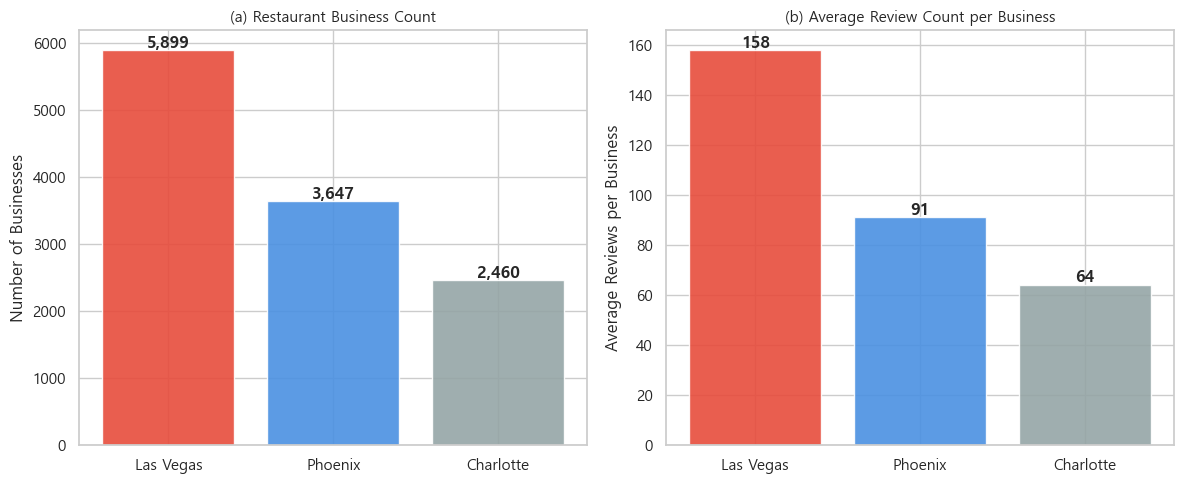

저장 완료: fig1_city_comparison.png


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 도시별 데이터 준비
cities = ['Las Vegas', 'Phoenix', 'Charlotte']

# 업체 수
business_counts = []
for city in cities:
    n = business_raw[
        business_raw['categories'].str.contains('Restaurants', na=False) &
        (business_raw['city'] == city)
    ].shape[0]
    business_counts.append(n)

# 업체당 평균 리뷰수
avg_reviews = []
for city in cities:
    biz_city = business_raw[
        business_raw['categories'].str.contains('Restaurants', na=False) &
        (business_raw['city'] == city)
    ]
    reviews_city = review_raw[review_raw['business_id'].isin(biz_city['business_id'])]
    avg = reviews_city.groupby('business_id').size().mean()
    avg_reviews.append(round(avg))

print("업체 수:", business_counts)
print("평균 리뷰수:", avg_reviews)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#e74c3c', '#4a90e2', '#95a5a6']

# (a) 업체 수
bars1 = axes[0].bar(cities, business_counts, color=colors, alpha=0.9)
axes[0].set_title('(a) Restaurant Business Count', fontsize=11)
axes[0].set_ylabel('Number of Businesses')
for bar, val in zip(bars1, business_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', fontweight='bold')

# (b) 평균 리뷰수
bars2 = axes[1].bar(cities, avg_reviews, color=colors, alpha=0.9)
axes[1].set_title('(b) Average Review Count per Business', fontsize=11)
axes[1].set_ylabel('Average Reviews per Business')
for bar, val in zip(bars2, avg_reviews):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{PATH_to_save}/fig1_city_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: fig1_city_comparison.png")

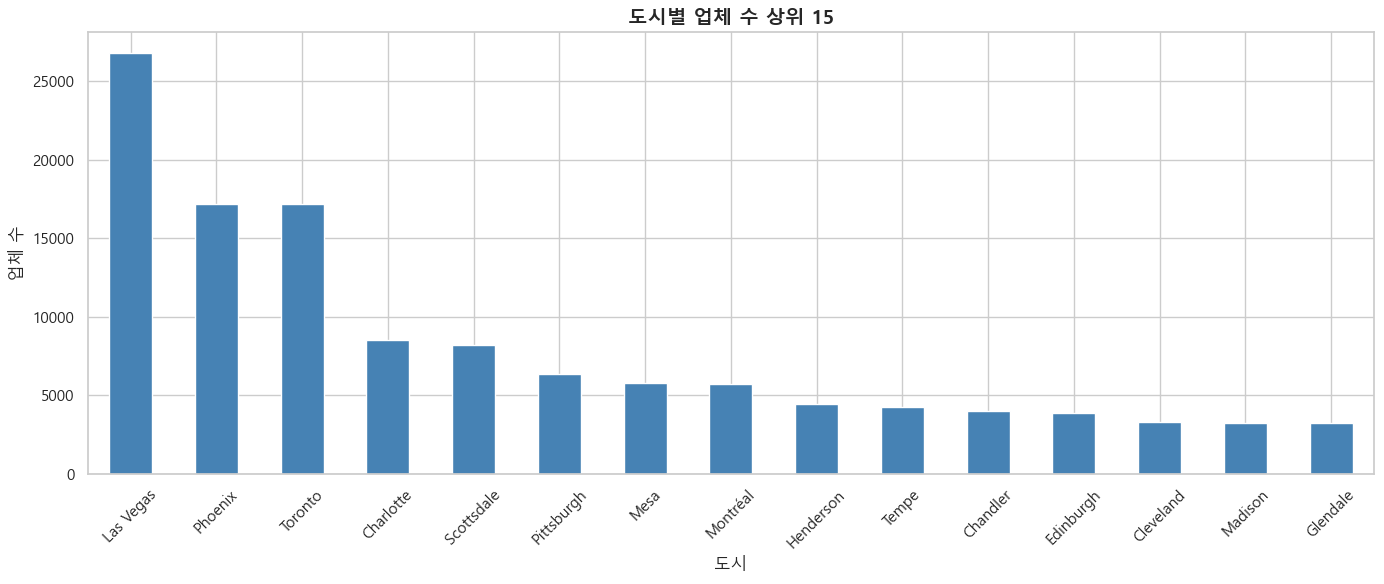

In [13]:
top_cities = business.groupby('city')['business_id'].count()\
                     .sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(14, 6))
top_cities.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('도시별 업체 수 상위 15', fontsize=14, fontweight='bold')
ax.set_xlabel('도시')
ax.set_ylabel('업체 수')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 1-4. 업종 선정 — Las Vegas 기준 프랜차이즈 비율 높은 업종 확인

업체 수가 가장 높은 **Las Vegas 전체 업체 기준으로 프랜차이즈 비율이 높은 업종**을 데이터로 확인한다.

- 업체 수 50개 미만 희소 업종 제외
- 프랜차이즈 판정 기준: 동일 브랜드명 10개 이상 출현 (임시 적용)

In [14]:
import re

def clean_name(name):
    name = name.lower().strip()
    name = re.sub(r'[^a-z0-9\s]', '', name)
    name = re.sub(r'\s+', ' ', name).strip()
    return name

# Las Vegas 전체 업체 (카테고리 제한 없이)
biz_lv = business[
    (business['state'] == 'NV') &
    (business['city'] == 'Las Vegas')
].copy()

biz_lv['name_clean'] = biz_lv['name'].apply(clean_name)
brand_cnt_lv = biz_lv.groupby('name_clean')['business_id'].count()
fc_brands_lv = brand_cnt_lv[brand_cnt_lv >= 10].index
biz_lv['is_franchise'] = biz_lv['name_clean'].isin(fc_brands_lv)

cat_exploded = biz_lv.assign(
    cat=biz_lv['categories'].str.split(';')
).explode('cat')
cat_exploded['cat'] = cat_exploded['cat'].str.strip()

cat_stats = cat_exploded.groupby('cat').agg(
    total=('business_id', 'count'),
    franchise=('is_franchise', 'sum')
).reset_index()
cat_stats['franchise_ratio'] = cat_stats['franchise'] / cat_stats['total'] * 100
cat_stats = cat_stats[cat_stats['total'] >= 50].sort_values('franchise_ratio', ascending=False)

print('=== 프랜차이즈 비율 높은 업종 상위 20 ===')
print(cat_stats[['cat', 'total', 'franchise', 'franchise_ratio']].head(20).to_string(index=False))

=== 프랜차이즈 비율 높은 업종 상위 20 ===
                          cat  total  franchise  franchise_ratio
                    Fast Food    884        615        69.570136
        Banks & Credit Unions    244        163        66.803279
           Convenience Stores    304        201        66.118421
                   Drugstores    208        135        64.903846
             Shipping Centers    132         84        63.636364
Photography Stores & Services     88         48        54.545455
                      Tex-Mex     75         38        50.666667
                     Notaries     95         48        50.526316
                 Gas Stations    278        138        49.640288
                      Burgers    531        225        42.372881
  Check Cashing/Pay-day Loans     76         32        42.105263
                   Sandwiches    655        261        39.847328
                Mobile Phones    190         73        38.421053
                       Donuts     79         30        37.974

In [15]:
# Restaurants 카테고리 직접 확인
print(cat_stats[cat_stats['cat'] == 'Restaurants'])

             cat  total  franchise  franchise_ratio
870  Restaurants   5899        937        15.884048


**결과 해석 및 업종 선정**:

| 업종 | 전체 | 프랜차이즈 비율 | 독립 브랜드 수 |
|---|---|---|---|
| Fast Food | 884 | 69.6% | 269개 |
| Burgers | 531 | 42.4% | 306개 |
| Sandwiches | 655 | 39.8% | 394개 |
| Coffee & Tea | 505 | 35.6% | 325개 |
| **Restaurants** | 5,899 | 15.7% | 4,974개 |

Fast Food, Burgers 등 프랜차이즈 비율이 높은 업종은 **독립 브랜드 절대 수가 너무 적어** 생존 브랜드 분석 시 표본 부족 문제가 발생한다.

Restaurants는 프랜차이즈 비율이 낮아 보이지만 **925개 프랜차이즈 + 4,974개 독립 브랜드**로 분석 볼륨이 압도적이며, 대형 프랜차이즈가 포함되어 FPI 효과 측정에 충분하다.

> **업종 확정: Restaurants**

### 1-5. 후보 도시 3개 비교 — 지도 시각화

업종(Restaurants)을 고정한 상태에서 **Las Vegas / Phoenix / Charlotte** 3개 도시를 비교한다.

- 산점도 지도: 프랜차이즈(빨강) vs 독립 브랜드(파랑) 혼재 정도 확인
- 히트맵: 리뷰수 기반 상권 밀집도 확인

In [16]:
import plotly.express as px

CANDIDATES = [
    {'state': 'NV', 'city': 'Las Vegas'},
    {'state': 'AZ', 'city': 'Phoenix'},
    {'state': 'NC', 'city': 'Charlotte'},
]
TARGET_CATEGORY = 'Restaurants'
FRANCHISE_THRESHOLD = 10

city_data = {}
for c in CANDIDATES:
    city, state = c['city'], c['state']
    df = business[
        (business['state'] == state) &
        (business['city'] == city) &
        (business['categories'].str.contains(TARGET_CATEGORY, na=False))
    ].copy()
    df['name_clean'] = df['name'].apply(clean_name)
    brand_cnt = df.groupby('name_clean')['business_id'].count()
    fc_brands = brand_cnt[brand_cnt >= FRANCHISE_THRESHOLD].index
    df['is_franchise'] = df['name_clean'].isin(fc_brands)
    df['type'] = df['is_franchise'].map({True: '프랜차이즈', False: '독립 브랜드'})
    city_data[city] = df
    n_fc = df['is_franchise'].sum()
    n_indie = (~df['is_franchise']).sum()
    print(f'{city:12} | 전체: {len(df):,}개 | 프랜차이즈: {n_fc:,}개 ({n_fc/len(df)*100:.1f}%) | 독립: {n_indie:,}개 ({n_indie/len(df)*100:.1f}%)')

Las Vegas    | 전체: 5,899개 | 프랜차이즈: 925개 (15.7%) | 독립: 4,974개 (84.3%)
Phoenix      | 전체: 3,647개 | 프랜차이즈: 592개 (16.2%) | 독립: 3,055개 (83.8%)
Charlotte    | 전체: 2,460개 | 프랜차이즈: 304개 (12.4%) | 독립: 2,156개 (87.6%)


In [17]:
summary = []
for city, df in city_data.items():
    n_fc = df['is_franchise'].sum()
    n_indie = (~df['is_franchise']).sum()
    summary.append({
        '도시': city,
        '전체 업체수': len(df),
        '프랜차이즈': n_fc,
        '독립 브랜드': n_indie,
        '프랜차이즈 비율(%)': round(n_fc / len(df) * 100, 1),
        '평균 별점': round(df['stars'].mean(), 2),
        '평균 리뷰수': round(df['review_count'].mean(), 0),
    })
summary_df = pd.DataFrame(summary)
print('=== 후보 도시 비교 요약 ===')
print(summary_df.to_string(index=False))

=== 후보 도시 비교 요약 ===
       도시  전체 업체수  프랜차이즈  독립 브랜드  프랜차이즈 비율(%)  평균 별점  평균 리뷰수
Las Vegas    5899    925    4974         15.7   3.46   158.0
  Phoenix    3647    592    3055         16.2   3.43    91.0
Charlotte    2460    304    2156         12.4   3.39    64.0


In [61]:
colors = {'프랜차이즈': '#E74C3C', '독립 브랜드': '#3498DB'}

for city, df in city_data.items():
    fig = px.scatter_mapbox(
        df, lat='latitude', lon='longitude',
        color='type', color_discrete_map=colors,
        hover_name='name',
        hover_data={'stars': True, 'review_count': True, 'type': True,
                    'latitude': False, 'longitude': False},
        zoom=11, height=550,
        title=f'{city} | 전체 {len(df):,}개 | 프랜차이즈 {df["is_franchise"].sum()}개({df["is_franchise"].mean()*100:.1f}%) | 독립 {(~df["is_franchise"]).sum()}개'
    )
    fig.update_layout(mapbox_style='open-street-map',
                      margin={'r': 0, 't': 50, 'l': 0, 'b': 0}, width=900)
    fig.update_traces(marker=dict(size=6, opacity=0.7))
    fig.write_html(f'map_{city.lower().replace(" ","_")}_scatter.html')
    fig.update_layout(width=600, height=600)
    fig.show()
    print()

In [62]:
for city, df in city_data.items():
    fig = px.density_mapbox(
        df, lat='latitude', lon='longitude',
        z='review_count', radius=20, zoom=11, height=500,
        color_continuous_scale='YlOrRd',
        title=f'{city} - 밀집도 히트맵 (리뷰수 기반)'
    )
    fig.update_layout(mapbox_style='open-street-map',
                      margin={'r': 0, 't': 50, 'l': 0, 'b': 0}, width=900)
    fig.write_html(f'map_{city.lower().replace(" ","_")}_heatmap.html')
    fig.update_layout(width=600, height=600)
    fig.show()
    print()

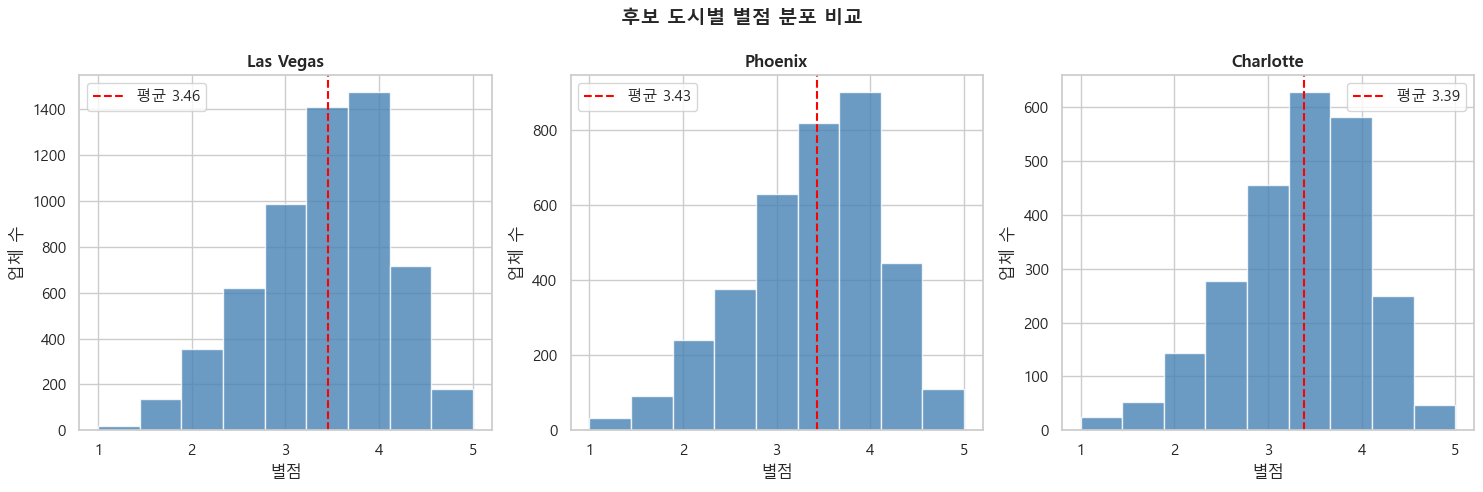

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (city, df) in zip(axes, city_data.items()):
    df['stars'].hist(ax=ax, bins=9, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(df['stars'].mean(), color='red', linestyle='--',
               label=f'평균 {df["stars"].mean():.2f}')
    ax.set_title(f'{city}', fontweight='bold')
    ax.set_xlabel('별점')
    ax.set_ylabel('업체 수')
    ax.legend()
plt.suptitle('후보 도시별 별점 분포 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 1-6. 최종 지역/업종 확정

**지도 및 수치 비교 결과**:

| 기준 | Las Vegas | Phoenix | Charlotte |
|---|---|---|---|
| 전체 업체수 | **5,899개** | 3,647개 | 2,460개 |
| 프랜차이즈 비율 | 15.7% | **16.2%** | 12.4% |
| 독립 브랜드 수 | **4,974개** | 3,055개 | 2,156개 |
| 평균 별점 | **3.46** | 3.43 | 3.39 |
| 평균 리뷰수 | **158개** | 91개 | 64개 |
| 상권 밀집 패턴 | 스트립 중심 고밀집 | 격자형 분산 | 다운타운 집중 |

**Las Vegas 선정 이유**:
- 업체 수, 리뷰수 모두 압도적 → 텍스트 분석 볼륨 확보
- 스트립(Paradise 구역) 중심 밀집 + 외곽 분산 구조 → FPI 거리 효과 측정에 최적
- 프랜차이즈/독립 브랜드 혼재 비율 균형적 (15.7% vs 84.3%)

> **최종 확정: Las Vegas (NV) / Restaurants**

In [19]:
TARGET_STATE    = 'NV'
TARGET_CITY     = 'Las Vegas'
TARGET_CATEGORY = 'Restaurants'

biz_target = city_data[TARGET_CITY].copy()

print('=' * 40)
print('STEP 1 완료 — 분석 대상 확정')
print('=' * 40)
print(f'지역  : {TARGET_CITY}, {TARGET_STATE}')
print(f'업종  : {TARGET_CATEGORY}')
print(f'업체수: {len(biz_target):,}개')

STEP 1 완료 — 분석 대상 확정
지역  : Las Vegas, NV
업종  : Restaurants
업체수: 5,899개


---
## STEP 2 — 프랜차이즈 판정

**목표**: 데이터 내에서 프랜차이즈와 독립 브랜드를 구분한다.

**판정 방법**: 동일한 브랜드명(name_clean)이 10개 이상 출현하면 프랜차이즈로 정의.

**진행 순서**:
1. 브랜드명 정제
2. 브랜드별 출현 횟수 집계
3. 민감도 분석 (기준값별 결과 비교)
4. 기준 확정 및 프랜차이즈/독립 브랜드 분리

### 2-1. 브랜드명 정제

브랜드명은 대소문자, 특수문자, 공백 등이 혼재해 동일 브랜드가 다르게 인식될 수 있다.
소문자화, 특수문자 제거, 공백 정리를 통해 정제한다.

In [21]:
import re

def clean_name(name):
    name = name.lower().strip()
    name = re.sub(r'[^a-z0-9\s]', '', name)
    name = re.sub(r'\s+', ' ', name).strip()
    return name

# biz_target은 STEP 1에서 확정된 Las Vegas Restaurants 데이터
biz_target['name_clean'] = biz_target['name'].apply(clean_name)

print('=== 브랜드명 정제 예시 ===')
print(biz_target[['name', 'name_clean']].head(10).to_string(index=False))

=== 브랜드명 정제 예시 ===
                                 name                          name_clean
            "Flight Deck Bar & Grill"               flight deck bar grill
                             "Subway"                              subway
                          "GameWorks"                           gameworks
                     "Cafe Mastrioni"                      cafe mastrioni
                         "McDonald's"                           mcdonalds
"Divine Cafe at the Springs Preserve" divine cafe at the springs preserve
                             "Subway"                              subway
               "Geebee's Bar & Grill"                   geebees bar grill
                   "Trattoria Italia"                    trattoria italia
                 "Cancun Bar & Grill"                    cancun bar grill


### 2-2. 브랜드별 출현 횟수 집계

정제된 브랜드명 기준으로 동일 브랜드가 몇 개의 업체를 운영하는지 집계한다.

In [35]:
brand_counts = biz_target.groupby('name_clean')['business_id'].count()\
                          .sort_values(ascending=False)

print('=== 브랜드 출현 횟수 상위 60 ===')
print(brand_counts.head(60))

=== 브랜드 출현 횟수 상위 60 ===
name_clean
subway                              117
mcdonalds                            90
robertos taco shop                   44
panda express                        41
jack in the box                      40
taco bell                            40
burger king                          40
pizza hut                            35
pts                                  33
port of subs                         31
del taco                             29
carls jr                             28
capriottis sandwich shop             23
wendys                               23
dennys                               21
popeyes louisiana kitchen            21
kfc                                  20
chipotle mexican grill               20
el pollo loco                        20
dominos pizza                        19
papa johns pizza                     17
little caesars pizza                 16
sonic drivein                        15
ihop                                 14
tropi

### 2-2-1. 브랜드명 불일치 케이스 수동 보정

브랜드명 정제 후에도 동일 브랜드가 다른 이름으로 분리되는 케이스가 발견되었다.
자동 정제만으로는 해결되지 않는 명확한 케이스를 수동으로 병합한다.

**발견된 케이스**:
- `einstein bros` + `einstein bros bagels` → 동일 브랜드, 합산 시 14개

In [36]:
# 유사 브랜드명 확인 (einstein 계열)
print(biz_target[biz_target['name_clean'].str.contains('einstein')][['name', 'name_clean']].value_counts())
print()
# robertos 계열도 확인 (로컬 체인인지)
print(biz_target[biz_target['name_clean'].str.contains('roberto')][['name', 'name_clean']].value_counts())

name                    name_clean          
"Einstein Bros"         einstein bros           7
"Einstein Bros Bagels"  einstein bros bagels    7
Name: count, dtype: int64

name                       name_clean           
"Roberto's Taco Shop"      robertos taco shop       38
"Robertos Taco Shop"       robertos taco shop        6
"Roberto's Taco Shop #22"  robertos taco shop 22     1
"Roberto's Tacos"          robertos tacos            1
Name: count, dtype: int64


In [40]:
# 수동 브랜드명 병합
name_mapping = {
    'einstein bros bagels': 'einstein bros',
}

biz_target['name_clean'] = biz_target['name_clean'].replace(name_mapping)

# 보정 후 확인
print('=== 보정 후 einstein bros 집계 ===')
print(biz_target[biz_target['name_clean'].str.contains('einstein')]\
      [['name', 'name_clean']].value_counts())
print()

# 브랜드 출현 횟수 재집계
brand_counts = biz_target.groupby('name_clean')['business_id'].count()\
                          .sort_values(ascending=False)
print('=== 보정 후 상위 30 ===')
print(brand_counts.head(30))

=== 보정 후 einstein bros 집계 ===
name                    name_clean   
"Einstein Bros"         einstein bros    7
"Einstein Bros Bagels"  einstein bros    7
Name: count, dtype: int64

=== 보정 후 상위 30 ===
name_clean
subway                       117
mcdonalds                     90
robertos taco shop            44
panda express                 41
burger king                   40
taco bell                     40
jack in the box               40
pizza hut                     35
pts                           33
port of subs                  31
del taco                      29
carls jr                      28
capriottis sandwich shop      23
wendys                        23
dennys                        21
popeyes louisiana kitchen     21
kfc                           20
el pollo loco                 20
chipotle mexican grill        20
dominos pizza                 19
papa johns pizza              17
little caesars pizza          16
sonic drivein                 15
einstein bros                 

**보정 결과**: `einstein bros bagels`가 `einstein bros`로 통합되어 14개로 집계된다.
추가로 발견되는 케이스가 있으면 `name_mapping`에 추가하여 관리한다.

In [ ]:
# 유사 브랜드명 자동 탐지
# 앞 1단어가 같은 브랜드 그룹 확인
first_word = brand_counts.reset_index()
first_word['first_word'] = first_word['name_clean'].str.split().str[0]
suspicious = first_word.groupby('first_word').filter(lambda x: len(x) > 1)
suspicious = suspicious.sort_values('first_word')
print(suspicious.to_string(index=False))

In [45]:
name_mapping = {
    'einstein bros bagels': 'einstein bros',
    'arbys roast beef sandwich restaurants': 'arbys',
    'little caesars pizza': 'little caesars',
    'little ceasars pizza': 'little caesars',
    'little ceasars': 'little caesars',
    'dairy queen grill chill': 'dairy queen',
    'dairy queen orange julius treat center': 'dairy queen',
    'popeyes lousiana kitchen': 'popeyes louisiana kitchen',
    'popeyes famous fried chicken and biscuits': 'popeyes louisiana kitchen',
    'popeyes chicken and biscuits': 'popeyes louisiana kitchen',
    'carls jr restaurants': 'carls jr',
    'carls jr and green burrito': 'carls jr',
    'chuck e cheese': 'chuck e cheeses',
    'sonic': 'sonic drivein',
    'jimmy johns gourmet sandwiches': 'jimmy johns',
    'capriottis': 'capriottis sandwich shop',
    'baja fresh mexican grill': 'baja fresh',
    'baja fresh las vegas': 'baja fresh',
    'dq grill chill': 'dairy queen',
    'dq grill chill restaurant': 'dairy queen',
}

biz_target['name_clean'] = biz_target['name_clean'].replace(name_mapping)

# 재집계
brand_counts = biz_target.groupby('name_clean')['business_id'].count()\
                          .sort_values(ascending=False)
print('=== 보정 후 상위 50 ===')
print(brand_counts.head(50))

=== 보정 후 상위 50 ===
name_clean
subway                              117
mcdonalds                            90
robertos taco shop                   44
panda express                        41
taco bell                            40
jack in the box                      40
burger king                          40
pizza hut                            35
pts                                  33
carls jr                             32
port of subs                         31
del taco                             29
capriottis sandwich shop             25
popeyes louisiana kitchen            24
wendys                               23
little caesars                       21
dennys                               21
chipotle mexican grill               20
el pollo loco                        20
kfc                                  20
dominos pizza                        19
papa johns pizza                     17
dairy queen                          17
sonic drivein                        16
einstein b

### 2-3. 민감도 분석 — 기준값별 프랜차이즈 판정 결과 비교

기준값(threshold)에 따라 프랜차이즈로 판정되는 브랜드 수와 업체 수가 달라진다.
3, 5, 10, 15, 20개 기준으로 비교해 최적 기준을 선택한다.

In [44]:
thresholds = [3, 5, 7, 10, 15, 20]
print('=== 프랜차이즈 판정 기준별 결과 (보정 후) ===')
print(f'{"기준":>6} | {"프랜차이즈 브랜드 수":>18} | {"프랜차이즈 업체 수":>18} | {"독립 업체 수":>12} | {"프랜차이즈 비율":>10}')
print('-' * 75)
for thr in thresholds:
    fc_brands = brand_counts[brand_counts >= thr]
    fc_biz    = biz_target[biz_target['name_clean'].isin(fc_brands.index)]
    indie_biz = biz_target[~biz_target['name_clean'].isin(fc_brands.index)]
    ratio     = len(fc_biz) / len(biz_target) * 100
    print(f'{thr:>6} | {len(fc_brands):>18} | {len(fc_biz):>18} | {len(indie_biz):>12} | {ratio:>9.1f}%')

=== 프랜차이즈 판정 기준별 결과 (보정 후) ===
    기준 |        프랜차이즈 브랜드 수 |         프랜차이즈 업체 수 |      독립 업체 수 |   프랜차이즈 비율
---------------------------------------------------------------------------
     3 |                181 |               1598 |         4301 |      27.1%
     5 |                 85 |               1278 |         4621 |      21.7%
     7 |                 56 |               1123 |         4776 |      19.0%
    10 |                 38 |                984 |         4915 |      16.7%
    15 |                 24 |                815 |         5084 |      13.8%
    20 |                 20 |                746 |         5153 |      12.6%


**민감도 분석 결과 해석**:

| 기준 | 프랜차이즈 브랜드 수 | 프랜차이즈 업체 수 | 프랜차이즈 비율 |
|---|---|---|---|
| 3개 | 181개 | 1,598개 | 27.1% |
| 5개 | 85개 | 1,278개 | 21.7% |
| 7개 | 56개 | 1,123개 | 19.0% |
| **10개** | **38개** | **984개** | **16.7%** |
| 15개 | 24개 | 815개 | 13.8% |
| 20개 | 20개 | 746개 | 12.6% |

- 3~5개 기준은 소규모 다점포 독립 브랜드까지 프랜차이즈로 오분류할 가능성이 높음
- 15~20개 기준은 실제 프랜차이즈 일부가 독립 브랜드로 분류될 수 있음
- **10개 기준**에서 subway, mcdonalds, burger king 등 명확한 프랜차이즈가 안정적으로 포함됨
- 7개 기준(1,123개)이랑 10개 기준(984개) 차이가 크지 않아서 7개로 낮출 필요 없음

> **프랜차이즈 판정 기준 확정: 동일 브랜드명 10개 이상**

### 2-4. 명확한 프랜차이즈 수동 추가 (화이트리스트)

10개 기준 미달이지만 라스베가스 내 지점 수가 적을 뿐, 전국적으로 운영되는 명확한 프랜차이즈 브랜드를 화이트리스트로 추가한다.

**현실적인 판단:**
> 기준을 낮추면 애매한 로컬 체인도 더 많이 들어올 가능성 있음. 기준을 낮추기 보다 Cafe Rio(9개), Raising Cane's(9개), Fatburger(9개) 같은 명확한 전국 프랜차이즈를 수동으로 추가하여 화이트리스트로 관리

| 브랜드 | 데이터 내 지점 수 | 판정 |
|---|---|---|
| Cafe Rio | 9개 | 화이트리스트 추가 |
| Raising Cane's | 9개 | 화이트리스트 추가 |
| Fatburger | 9개 | 화이트리스트 추가 |
| Teriyaki Madness | 9개 | 화이트리스트 추가 |
| Long John Silver's | 8개 | 화이트리스트 추가 |
| TGI Fridays | 8개 | 화이트리스트 추가 |
| Wienerschnitzel | 8개 | 화이트리스트 추가 |
| Applebee's | 8개 | 화이트리스트 추가 |
| Papa Murphy's | 8개 | 화이트리스트 추가 |
| California Pizza Kitchen | 7개 | 화이트리스트 추가 |
| Chili's | 7개 | 화이트리스트 추가 |
| Checkers | 7개 | 화이트리스트 추가 |

In [46]:
# 화이트리스트 — 기준 미달이지만 명확한 전국 프랜차이즈
manual_franchises = [
    'cafe rio', #  미국 유타에서 시작한 멕시칸 패스트캐주얼 체인
    'raising canes', # 미국 루이지애나 기반 체인
    'fatburger', # 미국 캘리포니아 기반 체인
    'teriyaki madness', # 미국에서 시작한 테리야키 체인
    'long john silvers', #미국 해산물 패스트푸드 체인
    'tgi fridays', # 미국에서 시작한 레스토랑 체인
    'wienerschnitzel', # 미국에서 시작한 핫도그 체인
    'applebees neighborhood grill bar', 
    'papa murphys', 
    'california pizza kitchen',
    'chilis', 
    'checkers', 
]

# 기존 프랜차이즈 브랜드 목록에 화이트리스트 추가
franchise_brands_base = set(brand_counts[brand_counts >= FRANCHISE_THRESHOLD].index)
franchise_brands_final = franchise_brands_base.union(set(manual_franchises))

biz_target['is_franchise'] = biz_target['name_clean'].isin(franchise_brands_final)

n_franchise = biz_target['is_franchise'].sum()
n_indie     = (~biz_target['is_franchise']).sum()

print(f'판정 기준        : 브랜드명 {FRANCHISE_THRESHOLD}개 이상 + 화이트리스트 {len(manual_franchises)}개')
print(f'총 프랜차이즈 브랜드 수: {len(franchise_brands_final)}개')
print(f'프랜차이즈 업체  : {n_franchise:,}개 ({n_franchise/len(biz_target)*100:.1f}%)')
print(f'독립 브랜드      : {n_indie:,}개 ({n_indie/len(biz_target)*100:.1f}%)')

판정 기준        : 브랜드명 10개 이상 + 화이트리스트 12개
총 프랜차이즈 브랜드 수: 50개
프랜차이즈 업체  : 1,081개 (18.3%)
독립 브랜드      : 4,818개 (81.7%)


**STEP 2 최종 결과:**

- 프랜차이즈: 1,081개 (18.3%)
- 독립 브랜드: 4,818개 (81.7%)
- 총 프랜차이즈 브랜드: 50개 (기준 충족 38개 + 화이트리스트 12개)

- 보정 전(925개) 대비 156개 더 정확하게 잡힘

### 2-5. 프랜차이즈 vs 독립 브랜드 기본 성과 비교

최종 판정 결과를 바탕으로 두 그룹의 별점과 리뷰수 분포를 비교한다.
이 비교는 FPI 분석 전 두 그룹의 기본 특성 차이를 확인하는 탐색적 분석이다.

In [51]:
compare = biz_target.groupby('is_franchise')[['stars', 'review_count']]\
                    .agg(['mean', 'median']).round(2)
compare.index = ['독립 브랜드', '프랜차이즈']
print('=== 프랜차이즈 vs 독립 브랜드 기본 비교 ===')
print(compare)

=== 프랜차이즈 vs 독립 브랜드 기본 비교 ===
       stars        review_count       
        mean median         mean median
독립 브랜드  3.63    3.5       183.49   58.0
프랜차이즈   2.71    2.5        42.13   24.0


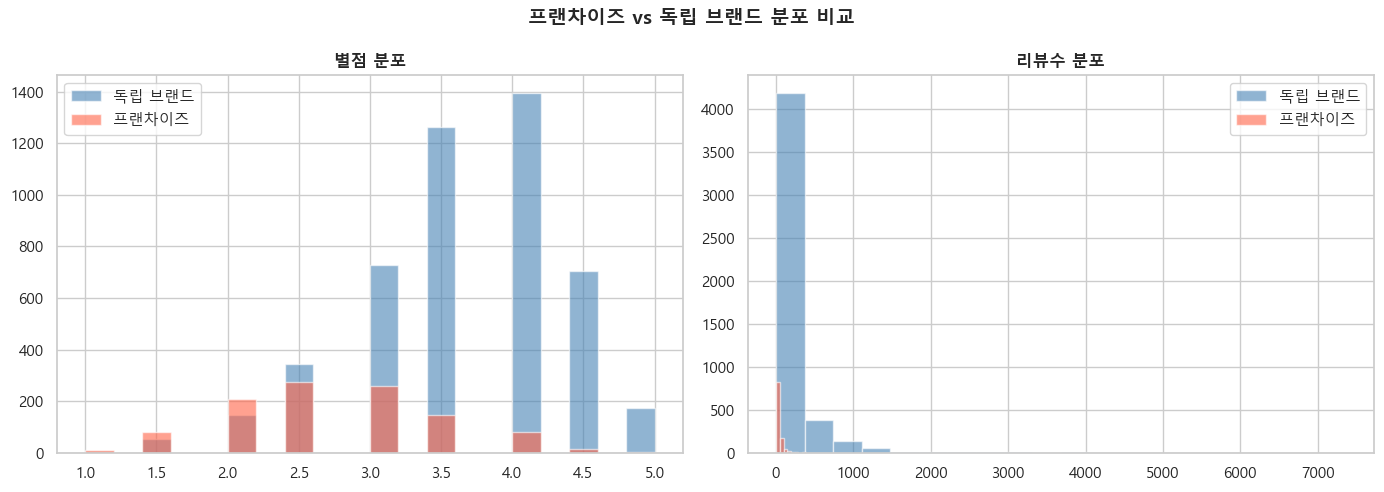

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(
    axes,
    ['stars', 'review_count'],
    ['별점 분포', '리뷰수 분포']
):
    biz_target[biz_target['is_franchise'] == False][col].hist(
        ax=ax, bins=20, alpha=0.6, label='독립 브랜드', color='steelblue'
    )
    biz_target[biz_target['is_franchise'] == True][col].hist(
        ax=ax, bins=20, alpha=0.6, label='프랜차이즈', color='tomato'
    )
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.suptitle('프랜차이즈 vs 독립 브랜드 분포 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**결과 해석**:
- 프랜차이즈(평균 2.71점)가 독립 브랜드(평균 3.63점)보다 별점이 낮게 나타났다.
  이는 Yelp 리뷰의 특성상 불만족 고객이 더 적극적으로 리뷰를 남기는 경향과,
  프랜차이즈의 높은 방문객 수로 인한 부정 리뷰 누적으로 해석할 수 있다.
- 리뷰수도 독립 브랜드(평균 183개)가 프랜차이즈(평균 42개)보다 많다.
  라스베가스 특성상 독립 레스토랑이 관광객 사이 입소문을 타는 경우가 많기 때문으로 보인다.
- 이러한 기초 차이를 확인한 상태에서 FPI 분석을 진행한다.

**주의**: 프랜차이즈의 낮은 별점과 리뷰수는 **Yelp 사용자의 독립 레스토랑 선호 편향**(Yelp에 리뷰 남기는 사람들이 독립 레스토랑 선호 성향일 수 있음),
**소비자의 높은 기대치**(프랜차이즈는 소비자 기대치가 높아서 같은 품질이어도 더 낮은 별점을 받을 수 있음), **라스베가스 관광객의 리뷰 패턴**(관광객들이 현지 독립 레스토랑을 더 적극적으로 Yelp에 리뷰하는 경향) 등 복합적 요인의 결과일 수 있다.
실제 방문객 수와 리뷰수는 직접적으로 비례하지 않을 수 있음을 유의한다.

In [53]:
# 리뷰 데이터 필터링
review_target = review[
    review['business_id'].isin(biz_target['business_id'])
].copy()

print(f'분석 대상 리뷰 수: {len(review_target):,}개')
print(f'분석 대상 업체 수: {review_target["business_id"].nunique():,}개')

분석 대상 리뷰 수: 929,606개
분석 대상 업체 수: 5,899개


### 2-6. 리뷰 데이터 필터링 및 저장

STEP 0~2에서 확정된 분석 대상(biz_target) 데이터와 분석 대상 업체에 해당하는 리뷰만 추출하고 저장한다.

이후 STEP 3~8의 모든 분석은 이 데이터를 기반으로 진행된다.

In [60]:
# 최종 데이터 저장
import os
os.makedirs('../results', exist_ok=True)

biz_target.to_csv('../results/biz_target.csv', index=False, encoding='utf-8-sig')
review_target.to_csv('../results/review_target.csv', index=False, encoding='utf-8-sig')

print('저장 완료')
print(f'results/biz_target.csv    : {len(biz_target):,}행')
print(f'results/review_target.csv : {len(review_target):,}행')
print()
print('=' * 40)
print('STEP 0, 1, 2 완료')
print('=' * 40)
print(f'지역      : Las Vegas, NV')
print(f'업종      : Restaurants')
print(f'기준      : 브랜드명 10개 이상+ 화이트리스트 12개 = 프랜차이즈')
print(f'전체 업체 : {len(biz_target):,}개')
print(f'프랜차이즈: {n_franchise:,}개')
print(f'독립 브랜드: {n_indie:,}개')
print(f'분석 리뷰 : {len(review_target):,}개')

저장 완료
results/biz_target.csv    : 5,899행
results/review_target.csv : 929,606행

STEP 0, 1, 2 완료
지역      : Las Vegas, NV
업종      : Restaurants
기준      : 브랜드명 10개 이상+ 화이트리스트 12개 = 프랜차이즈
전체 업체 : 5,899개
프랜차이즈: 1,081개
독립 브랜드: 4,818개
분석 리뷰 : 929,606개


### 2-7. 프랜차이즈/독립 브랜드 분포 지도 시각화

최종 판정 결과를 지도에 시각화한다.
- **빨강**: 프랜차이즈
- **파랑**: 독립 브랜드

In [57]:
# folium 버전 (탐색용)
import folium

center_lat = biz_target['latitude'].mean()
center_lon = biz_target['longitude'].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

sample = biz_target.sample(min(500, len(biz_target)), random_state=42)
for _, row in sample.iterrows():
    color = 'red' if row['is_franchise'] else 'blue'
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=4,
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=f"{row['name']} ({'프랜차이즈' if row['is_franchise'] else '독립'})"
    ).add_to(m)

m.save('../results/step2_franchise_map_folium.html')
print('folium 지도 저장: results/step2_franchise_map_folium.html')

folium 지도 저장: results/step2_franchise_map_folium.html


#### Plotly 버전 (보고서용 — 전체 5,899개)

전체 업체를 대상으로 인터랙티브 지도를 생성한다.
스트립(Paradise 구역) 중심으로 프랜차이즈가 밀집되어 있으며,
독립 브랜드는 도시 전체에 고르게 분포하는 패턴을 확인할 수 있다.

In [58]:
# plotly 버전 (보고서용)
biz_map = biz_target.copy()
biz_map['유형'] = biz_map['is_franchise'].map({True: '프랜차이즈', False: '독립 브랜드'})

fig = px.scatter_mapbox(
    biz_map,
    lat='latitude', lon='longitude',
    color='유형',
    color_discrete_map={'프랜차이즈': '#E74C3C', '독립 브랜드': '#3498DB'},
    hover_name='name',
    hover_data={'stars': True, 'review_count': True, '유형': True,
                'latitude': False, 'longitude': False},
    zoom=11, height=600,
    title=f'Las Vegas Restaurants | 프랜차이즈 {n_franchise:,}개 ({n_franchise/len(biz_target)*100:.1f}%) | 독립 브랜드 {n_indie:,}개 ({n_indie/len(biz_target)*100:.1f}%)'
)
fig.update_layout(mapbox_style='open-street-map',
                  margin={'r': 0, 't': 50, 'l': 0, 'b': 0}, width=900)
fig.update_traces(marker=dict(size=6, opacity=0.7))
fig.write_html('../results/step2_franchise_map_plotly.html')
print('plotly 지도 저장: results/step2_franchise_map_plotly.html')
fig.show()

plotly 지도 저장: results/step2_franchise_map_plotly.html


---
## STEP 2 완료 — 프랜차이즈 판정 요약

| 항목 | 내용 |
|---|---|
| 분석 지역 | Las Vegas, NV |
| 분석 업종 | Restaurants |
| 판정 기준 | 브랜드명 10개 이상 + 화이트리스트 12개 |
| 총 프랜차이즈 브랜드 | 50개 |
| 프랜차이즈 업체 | 1,081개 (18.3%) |
| 독립 브랜드 | 4,818개 (81.7%) |
| 분석 대상 리뷰 | 929,606개 |

> 다음 단계: STEP 3 — 텍스트 전처리 및 DTM/TF-IDF 구축 

*1. 브랜드명 10개 이상 등장 (자동 판정)*
- 데이터 기반. Las Vegas 내 10개 이상 지점이 있으면 프랜차이즈로 자동 판정.

*2. 수동 화이트리스트 (주관적)*
- 10개 미만이지만 명백한 프랜차이즈인 브랜드들을 추가. 

*근거*:
- 연구자 판단 ("이건 누가 봐도 프랜차이즈")
- 독립 브랜드 중 다점포 확인 후 추가

---
# STEP 0-2 분석 정리 (보고서용)

## 1. 데이터 개요

| 파일 | 행 수 | 주요 컬럼 |
|---|---|---|
| yelp_business.csv | 174,566개 | business_id, name, city, state, latitude, longitude, stars, review_count, categories |
| yelp_review.csv | 5,261,668개 | review_id, business_id, stars, text, date |

- 결측치: business 1행 제거, review 결측치 없음

---

## 2. 분석 대상 선정 (지역/업종)

**선정 결과: Las Vegas, NV / Restaurants**

**선정 과정**:
- 전체 데이터 기준 주별 업체 수 및 도시별 리뷰수 확인
- Las Vegas, Phoenix, Charlotte 3개 도시를 후보로 선정해 비교 분석 진행

| 기준 | Las Vegas | Phoenix | Charlotte |
|---|---|---|---|
| 전체 업체수 | **5,899개** | 3,647개 | 2,460개 |
| 프랜차이즈 비율 | 15.7% | 16.2% | 12.4% |
| 독립 브랜드 수 | **4,974개** | 3,055개 | 2,156개 |
| 평균 별점 | **3.46** | 3.43 | 3.39 |
| 평균 리뷰수 | **158개** | 91개 | 64개 |
| 전체 리뷰수 | **1,603,616개** | 576,700개 | 237,308개 |
| 상권 밀집 패턴 | 스트립 중심 고밀집 | 격자형 분산 | 다운타운 집중 |

**Las Vegas 선정 이유**:
- 업체 수, 리뷰수 모두 압도적 1위 → 텍스트 분석 볼륨 확보
- 스트립(Paradise 구역) 중심 밀집 + 외곽 분산 구조 → FPI 거리 효과 측정에 최적
- 프랜차이즈/독립 브랜드 혼재 균형적 (15.7% vs 84.3%)

**업종 선정 이유**:
- 업종별 프랜차이즈 비율 확인 결과 Fast Food(69.6%), Burgers(42.4%) 등은 프랜차이즈 비율이 높으나 독립 브랜드 절대 수가 부족해 생존 브랜드 분석 시 표본 부족 문제 발생
- Restaurants는 프랜차이즈 925개 + 독립 브랜드 4,974개로 분석 볼륨 압도적

---

## 3. 프랜차이즈 판정

**판정 기준**: 브랜드명 정제 후 동일 name 10개 이상 출현 + 화이트리스트 12개

**브랜드명 정제 방법**:
- 소문자화, 특수문자 제거, 공백 정리
- 유사 브랜드명 수동 병합 (Einstein Bros, Arby's, Little Caesars 등)

**민감도 분석 결과**:

| 기준 | 프랜차이즈 브랜드 수 | 프랜차이즈 업체 수 | 프랜차이즈 비율 |
|---|---|---|---|
| 3개 | 181개 | 1,598개 | 27.1% |
| 5개 | 85개 | 1,278개 | 21.7% |
| 7개 | 56개 | 1,123개 | 19.0% |
| **10개** | **38개** | **984개** | **16.7%** |
| 15개 | 24개 | 815개 | 13.8% |
| 20개 | 20개 | 746개 | 12.6% |

**화이트리스트 추가 (12개)**: Cafe Rio, Raising Cane's, Fatburger, Teriyaki Madness, Long John Silver's, TGI Fridays, Wienerschnitzel, Applebee's, Papa Murphy's, California Pizza Kitchen, Chili's, Checkers

**최종 판정 결과**:

| 구분 | 업체 수 | 비율 |
|---|---|---|
| 프랜차이즈 | 1,081개 | 18.3% |
| 독립 브랜드 | 4,818개 | 81.7% |
| 전체 | 5,899개 | 100% |

**한계**: 데이터 내 등록 방식 차이로 일부 프랜차이즈가 누락될 수 있음

*1. 브랜드명 10개 이상 등장 (자동 판정)*
- 데이터 기반. Las Vegas 내 10개 이상 지점이 있으면 프랜차이즈로 자동 판정.

*2. 수동 화이트리스트 (주관적)*
- 10개 미만이지만 명백한 프랜차이즈인 브랜드들을 추가. 

*근거*:
- 연구자 판단 ("이건 누가 봐도 프랜차이즈")
- 독립 브랜드 중 다점포 확인 후 추가


---

## 4. 프랜차이즈 vs 독립 브랜드 기초 비교

| | 평균 별점 | 중앙값 별점 | 평균 리뷰수 | 중앙값 리뷰수 |
|---|---|---|---|---|
| 독립 브랜드 | 3.63 | 3.5 | 183개 | 58개 |
| 프랜차이즈 | 2.71 | 2.5 | 42개 | 24개 |

- 프랜차이즈가 독립 브랜드보다 별점이 낮게 나타남
- Yelp 사용자의 독립 레스토랑 선호 편향, 높은 소비자 기대치, 라스베가스 관광객의 리뷰 패턴 등 복합적 요인으로 해석 가능
- 실제 방문객 수와 리뷰수는 직접 비례하지 않을 수 있음을 유의

---

## 5. 분석 대상 데이터 최종 확정

| 항목 | 내용 |
|---|---|
| 분석 지역 | Las Vegas, NV |
| 분석 업종 | Restaurants |
| 분석 대상 업체 | 5,899개 |
| 프랜차이즈 | 1,081개 (18.3%) |
| 독립 브랜드 | 4,818개 (81.7%) |
| 분석 대상 리뷰 | 929,606개 |
| 저장 파일 | results/biz_target.csv, results/review_target.csv |

> 다음 단계: STEP 3 — 텍스트 전처리 및 DTM/TF-IDF 구축 (담당: 민서)